# This notebook computes global MergedIR Tb data valid fraction, saves the annual mean data and plots maps
## The input data is produced by:
* calc_mergir_missing_data.py
## The plots:
* Pentad maps
* Annual maps

In [ ]:
import numpy as np
import glob
import xarray as xr
import time
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path
# %matplotlib inline

In [2]:
# datadir = '/pscratch/sd/w/wcmca1/GPM/IR_IMERG_Combined_V07B/stats/'
datadir = '/Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/'
datafiles = sorted(glob.glob(f'{datadir}merg_monthly_validcount_*nc'))

print(len(datafiles))

figdir = datadir

324


In [3]:
# Read data
# ds = xr.open_mfdataset(datafiles, concat_dim='time')
ds = xr.open_mfdataset(datafiles, concat_dim='time', combine='nested')
# Crop the region beyond 60S-60N
# ds = ds.where((ds.lat >= -60) & (ds.lat <= 60), drop=True)
ds

<xarray.Dataset> Size: 11GB
Dimensions:       (time: 324, lat: 1200, lon: 3600)
Coordinates:
  * time          (time) datetime64[ns] 3kB 1998-01-01 1998-02-01 ... 2024-12-01
  * lat           (lat) float64 10kB -59.95 -59.85 -59.75 ... 59.75 59.85 59.95
  * lon           (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
Data variables:
    count_00min   (time, lat, lon) float32 6GB dask.array<chunksize=(1, 600, 1800), meta=np.ndarray>
    count_30min   (time, lat, lon) float32 6GB dask.array<chunksize=(1, 600, 1800), meta=np.ndarray>
    ntimes_00min  (time) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    ntimes_30min  (time) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
    ntimes        (time) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    title:       Valid data counts
    contact:     Zhe Feng, zhe.feng@pnnl.gov
    created_on:  2026-06-08 16:33:45.229700

In [4]:
lon = ds.lon
lat = ds.lat
ntimes = ds.ntimes

In [5]:
frac00_all = ds.count_00min.sum(dim='time') / ds.ntimes_00min.sum(dim='time')
frac30_all = ds.count_30min.sum(dim='time') / ds.ntimes_30min.sum(dim='time')
frac00_all.load()
frac30_all.load()

<xarray.DataArray (lat: 1200, lon: 3600)> Size: 17MB
array([[0.34024826, 0.3399145 , 0.33808082, ..., 0.3483307 , 0.35322326,
        0.35426262],
       [0.6140076 , 0.6188072 , 0.61688906, ..., 0.63127095, 0.62630236,
        0.6235857 ],
       [0.84109324, 0.8414228 , 0.841482  , ..., 0.8442029 , 0.84401697,
        0.84673786],
       ...,
       [0.9778694 , 0.9779624 , 0.9779835 , ..., 0.9780722 , 0.97794545,
        0.97805953],
       [0.8663546 , 0.8712683 , 0.8693163 , ..., 0.8734188 , 0.8730343 ,
        0.8726456 ],
       [0.429886  , 0.43986124, 0.43695867, ..., 0.43967956, 0.43703473,
        0.43957818]], shape=(1200, 3600), dtype=float32)
Coordinates:
  * lat      (lat) float64 10kB -59.95 -59.85 -59.75 ... 59.75 59.85 59.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
Attributes:
    units:    count

In [6]:
# ds.ntimes_00min.groupby('time.year').sum(dim='time')
ds.time

<xarray.DataArray 'time' (time: 324)> Size: 3kB
array(['1998-01-01T00:00:00.000000000', '1998-02-01T00:00:00.000000000',
       '1998-03-01T00:00:00.000000000', ..., '2024-10-01T00:00:00.000000000',
       '2024-11-01T00:00:00.000000000', '2024-12-01T00:00:00.000000000'],
      shape=(324,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 1998-01-01 1998-02-01 ... 2024-12-01
Attributes:
    long_name:  Epoch Time (since 1970-01-01T00:00:00)

In [7]:
frac00_year = ds.count_00min.groupby('time.year').sum(dim='time') / ds.ntimes_00min.groupby('time.year').sum(dim='time')
frac30_year = ds.count_30min.groupby('time.year').sum(dim='time') / ds.ntimes_30min.groupby('time.year').sum(dim='time')
frac00_year.load()
frac30_year.load()
years = frac00_year.year

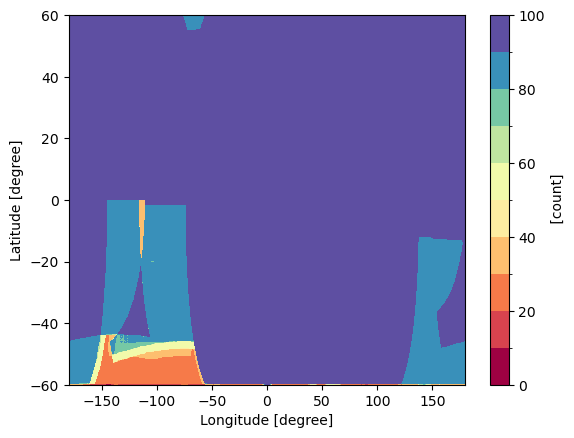

In [ ]:
levels = np.arange(0, 100.1, 10)
norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
(frac30_all*100).plot(norm=norm, cmap='Spectral')

In [10]:
np.arange(2000,2024,5), np.arange(2000,2024,5)

(array([2000, 2005, 2010, 2015, 2020]), array([2000, 2005, 2010, 2015, 2020]))

In [50]:
# pentad_bins = np.array([2000,2005,2010,2015,2020,2024])
# pentad_label = np.array([2000,2005,2010,2015,2020])
pentad_bins = np.array([1998,2000,2005,2010,2015,2020,2024])
pentad_label = np.array([1998,2000,2005,2010,2015,2020])
frac00_pentad = ds.count_00min.groupby_bins('time.year', bins=pentad_bins, labels=pentad_label).sum(dim='time') / ds.ntimes_00min.groupby_bins('time.year', bins=pentad_bins, labels=pentad_label).sum(dim='time')
frac30_pentad = ds.count_30min.groupby_bins('time.year', bins=pentad_bins, labels=pentad_label).sum(dim='time') / ds.ntimes_30min.groupby_bins('time.year', bins=pentad_bins, labels=pentad_label).sum(dim='time')
frac00_pentad.load()
frac30_pentad.load()

<xarray.DataArray (year_bins: 6, lat: 1200, lon: 3600)> Size: 104MB
array([[[0.3015448 , 0.30678904, 0.305877  , ..., 0.30564898,
         0.30536395, 0.30507895],
        [0.5638716 , 0.56803286, 0.5675768 , ..., 0.571852  ,
         0.56900185, 0.5699709 ],
        [0.79843813, 0.79917914, 0.7992362 , ..., 0.80573446,
         0.8056775 , 0.8072165 ],
        ...,
        [0.94955254, 0.94972354, 0.9497805 , ..., 0.94989455,
         0.94938153, 0.9500086 ],
        [0.80180126, 0.8035114 , 0.8045944 , ..., 0.8051075 ,
         0.8080716 , 0.8051075 ],
        [0.36384884, 0.36823803, 0.37086016, ..., 0.3737103 ,
         0.37200022, 0.37086016]],

       [[0.20851588, 0.21116284, 0.21029572, ..., 0.21193866,
         0.21182457, 0.21164203],
        [0.385063  , 0.38659182, 0.3871851 , ..., 0.3885086 ,
         0.38752738, 0.38777837],
        [0.49050748, 0.49066722, 0.49080414, ..., 0.49119204,
         0.4911692 , 0.49205914],
...
        [0.9656541 , 0.96558565, 0.9654488 , ..., 0.9657909 ,
         0.9657909 , 0.96590495],
        [0.8515326 , 0.85812354, 0.8523536 , ..., 0.8633233 ,
         0.8603129 , 0.8610655 ],
        [0.45101258, 0.46957672, 0.46668035, ..., 0.46626985,
         0.4653576 , 0.46453658]],

       [[0.3969028 , 0.39310974, 0.392026  , ..., 0.4218857 ,
         0.43663016, 0.43526125],
        [0.6901951 , 0.704141  , 0.6960415 , ..., 0.7401038 ,
         0.721937  , 0.71549165],
        [0.97969425, 0.9801791 , 0.9797228 , ..., 0.98040724,
         0.9806069 , 0.98189026],
        ...,
        [0.99874514, 0.99871665, 0.99871665, ..., 0.99871665,
         0.99874514, 0.9988878 ],
        [0.87209105, 0.8781371 , 0.8704369 , ..., 0.8836128 ,
         0.8809605 , 0.8813028 ],
        [0.42890143, 0.4463267 , 0.4430755 , ..., 0.44361737,
         0.44116473, 0.44050878]]], shape=(6, 1200, 3600), dtype=float32)
Coordinates:
  * year_bins  (year_bins) int64 48B 1998 2000 2005 2010 2015 2020
  * lat        (lat) float64 10kB -59.95 -59.85 -59.75 ... 59.75 59.85 59.95
  * lon        (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
Attributes:
    units:    count

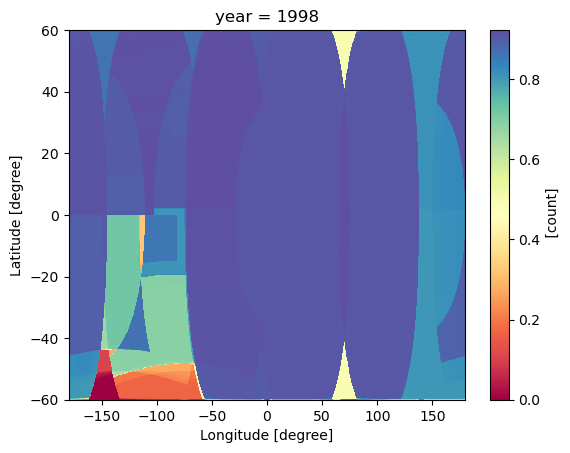

In [13]:
frac30_year.sel(year=1998).plot(cmap='Spectral')

In [48]:
# frac30_year.sel(year=1999).plot(cmap='Spectral')

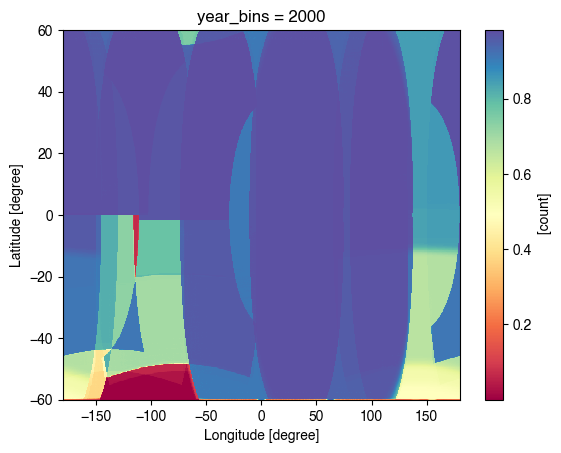

In [49]:
frac30_pentad.sel(year_bins=2000).plot(cmap='Spectral')

In [ ]:
# frac30_pentad.sel(year_bins=2005).plot(cmap='Spectral')

In [ ]:
# frac30_pentad.sel(year_bins=2015).plot(cmap='Spectral')

In [ ]:
# frac00_year.sel(year=2020).plot(cmap='Spectral')

In [16]:
ds.lon.min(), ds.lon.max(), ds.lat.min(), ds.lat.max()

(<xarray.DataArray 'lon' ()> Size: 8B
 array(-179.95)
 Attributes:
     long_name:  Longitude
     units:      degree,
 <xarray.DataArray 'lon' ()> Size: 8B
 array(179.95)
 Attributes:
     long_name:  Longitude
     units:      degree,
 <xarray.DataArray 'lat' ()> Size: 8B
 array(-59.95)
 Attributes:
     long_name:  Latitude
     units:      degree,
 <xarray.DataArray 'lat' ()> Size: 8B
 array(59.95)
 Attributes:
     long_name:  Latitude
     units:      degree)

In [ ]:
# frac30_all.plot(cmap='Spectral')

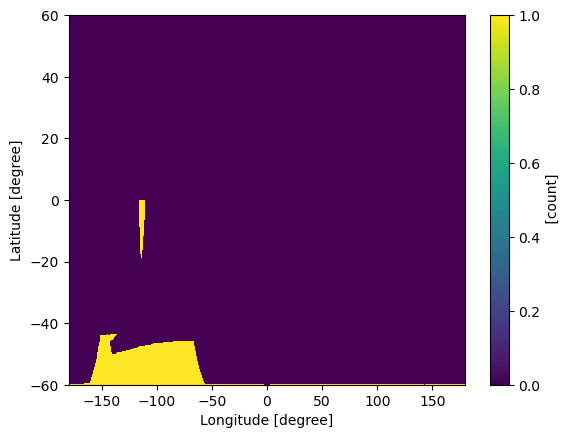

In [17]:
(frac30_all < 0.75).plot()

In [18]:
years

<xarray.DataArray 'year' (year: 27)> Size: 216B
array([1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009,
       2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024])
Coordinates:
  * year     (year) int64 216B 1998 1999 2000 2001 2002 ... 2021 2022 2023 2024

In [19]:
min_year = np.min(years.values)
max_year = np.max(years.values)
min_year, max_year

(np.int64(1998), np.int64(2024))

In [22]:
# Save annual fraction data to a netCDF file
out_filename = f'{datadir}merg_valid_fraction_{min_year}_{max_year}.nc'

dsmap = xr.Dataset(
    {
        'fraction_00min_all': (['lat', 'lon'], frac00_all.data),
        'fraction_30min_all': (['lat', 'lon'], frac30_all.data),
        'fraction_00min': (['year', 'lat', 'lon'], frac00_year.data),
        'fraction_30min': (['year', 'lat', 'lon'], frac30_year.data),
    },
    coords={
        'year': (['year'], years.values),
        'lat': (['lat'], lat.values),
        'lon': (['lon'], lon.values)
    },
    attrs={
        'title': 'MergIR valid data fraction',
        'contact':'Zhe Feng, zhe.feng@pnnl.gov',
        'created_on':time.ctime(time.time()),
        'produced_with':Path(globals()['__vsc_ipynb_file__']).name,
    },
)

dsmap.lon.attrs['long_name'] = 'Longitude'
dsmap.lon.attrs['units'] = 'degree'

dsmap.lat.attrs['long_name'] = 'Latitude'
dsmap.lat.attrs['units'] = 'degree'

dsmap.fraction_00min_all.attrs['long_name'] = 'Valid data fraction at 00min for all years'
dsmap.fraction_00min_all.attrs['units'] = 'fraction'

dsmap.fraction_30min_all.attrs['long_name'] = 'Valid data fraction at 30min for all years'
dsmap.fraction_30min_all.attrs['units'] = 'fraction'

dsmap.fraction_00min.attrs['long_name'] = 'Valid data fraction at 00min for each year'
dsmap.fraction_00min.attrs['units'] = 'fraction'

dsmap.fraction_30min.attrs['long_name'] = 'Valid data fraction at 30min for each year'
dsmap.fraction_30min.attrs['units'] = 'fraction'

fillvalue = np.nan
# Set encoding/compression for all variables
comp = dict(zlib=True, _FillValue=fillvalue, dtype='float32')
encoding = {var: comp for var in dsmap.data_vars}

dsmap.to_netcdf(path=out_filename, mode='w', format='NETCDF4', unlimited_dims='year', encoding=encoding)
print('Output saved as: ', out_filename)

Output saved as:  /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_valid_fraction_1998_2024.nc


In [23]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

In [51]:
def plot_map_pentad(nrow, ncol,dataarray, titles, figtitle, levels, cmap, cblabel, cbticks, figname, figsize=(10,8), oob_colors=None):
    
    mpl.rcParams['font.size'] = 7
    mpl.rcParams['font.family'] = 'Helvetica'

    map_extend = [-180., 180., -60.1, 60.1]
    lonvals = mpl.ticker.FixedLocator(np.arange(-180,180.1,30))
    latvals = mpl.ticker.FixedLocator(np.arange(-90,90.1,15))
    proj = ccrs.PlateCarree()

    fig = plt.figure(figsize=figsize, dpi=100)
    gs = gridspec.GridSpec(nrows=nrow, ncols=ncol, wspace=0.07, hspace=0.2)
    fig.text(0.5, 0.92, figtitle, fontsize=12, ha='center', va='center', transform=fig.transFigure, zorder=5)

    resolution = '110m'
    land = cfeature.NaturalEarthFeature('physical', 'land', resolution)
    # ocean = cfeature.NaturalEarthFeature('physical', 'ocean', resolution)
    # borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', resolution)

    for col in range(0,ncol):
        for row in range(0,nrow):
            ax = plt.subplot(gs[row,col], projection=proj)
            ax.set_extent(map_extend, crs=proj)
            ax.add_feature(land, facecolor='none', edgecolor='k', zorder=2)
            ax.set_title(titles[row][col], loc='left')
            ax.set_aspect('auto', adjustable=None)
            
            Zm = dataarray[row][col]
            cmap = plt.get_cmap(cmap)
            norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=cmap.N)
            cf1 = ax.pcolormesh(lon, lat, Zm, norm=norm, cmap=cmap, transform=proj, zorder=1)
            if oob_colors is not None:
                cf1.cmap.set_over(oob_colors['over'])
                cf1.cmap.set_under(oob_colors['under'])
                cf1.set_clim(min(levels), max(levels))

            # Draw gridlines and labels
            gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle='--', linewidth=0.5)
            gl.top_labels = False
            gl.right_labels = False
            if (col != 0):
                gl.left_labels = False
            if (row != nrow-1):
                gl.bottom_labels = False

    # Plot 1 colorbar by manually adding a new axes
    cax1 = fig.add_axes([0.91, 0.2, 0.015, 0.6])
    cb1 = plt.colorbar(cf1, cax=cax1, label=cblabel, ticks=cbticks, orientation='vertical')
    
    fig.savefig(figname, dpi=300, bbox_inches='tight', facecolor='w')
    return fig

nrow: 6, ncol: 2


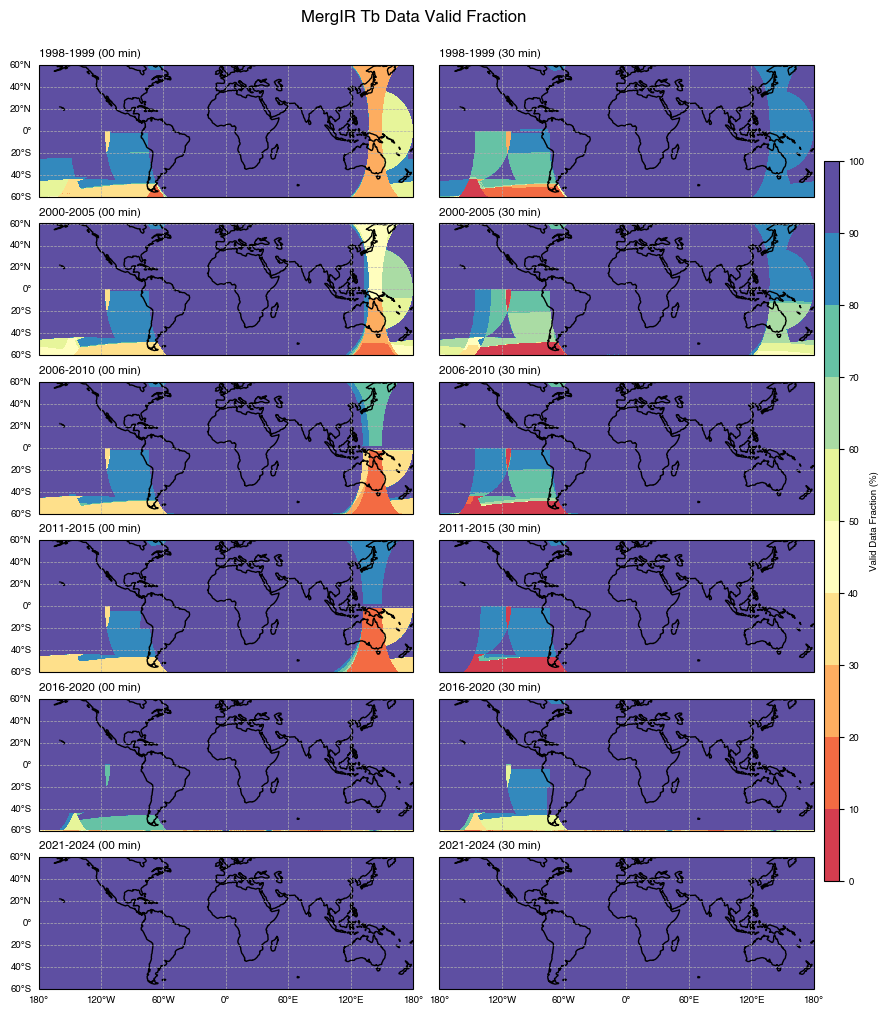

In [52]:
titles = [['1998-1999 (00 min)','2000-2005 (00 min)','2006-2010 (00 min)','2011-2015 (00 min)','2016-2020 (00 min)','2021-2024 (00 min)'],
          ['1998-1999 (30 min)','2000-2005 (30 min)','2006-2010 (30 min)','2011-2015 (30 min)','2016-2020 (30 min)','2021-2024 (30 min)']]
titles = np.array(titles).T.tolist()
dataarr = [
    [frac00_pentad[0]*100, frac30_pentad[0]*100],
    [frac00_pentad[1]*100, frac30_pentad[1]*100],
    [frac00_pentad[2]*100, frac30_pentad[2]*100],
    [frac00_pentad[3]*100, frac30_pentad[3]*100],
    [frac00_pentad[4]*100, frac30_pentad[4]*100],
    [frac00_pentad[5]*100, frac30_pentad[5]*100],
]
nrow = len(dataarr)
ncol = len(dataarr[0])
print(f"nrow: {nrow}, ncol: {ncol}")

min_nsample = 0
figtitle = 'MergIR Tb Data Valid Fraction'
levels = np.arange(0, 100.1, 10)
cbticks = levels
cblabel = 'Valid Data Fraction (%)'
cmap = plt.get_cmap('Spectral')
cmap = truncate_colormap(cmap, 0.1, 1)
figname = f'{figdir}merg_validdata_frac_pentad_{min_year}-{max_year}.png'
fig = plot_map_pentad(nrow, ncol, dataarr, titles, figtitle, levels, cmap, cblabel, cbticks, figname, figsize=(10,12))

In [37]:
figdir

'/Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/'

In [ ]:
def plot_2maps(dataarray, levels, cmap, cblabel, cbticks, titles, figname):
    
#     mpl.rcParams['font.size'] = 13
    mpl.rcParams['font.size'] = 10
    mpl.rcParams['font.family'] = 'Helvetica'

    map_extend = [-180, 180.1, -60.1, 60.1]
    lonvals = mpl.ticker.FixedLocator(np.arange(-180,180.1,60))
    latvals = mpl.ticker.FixedLocator(np.arange(-60,60.1,20))

    land = cfeature.NaturalEarthFeature('physical', 'land', '110m')
    ocean = cfeature.NaturalEarthFeature('physical', 'ocean', '110m')
    borders = cfeature.NaturalEarthFeature('cultural', 'admin_0_boundary_lines_land', '110m')
    
    fig = plt.figure(figsize=[10,7], dpi=100)

    for pp in range(0,2):
        data = dataarray[pp]

        ax = plt.subplot(2, 1, pp+1, projection=ccrs.PlateCarree())
        ax.set_extent(map_extend, crs=ccrs.PlateCarree())
        ax.add_feature(land, facecolor='none', edgecolor='k', zorder=5)
        ax.set_aspect('auto', adjustable=None)

        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linestyle='--', linewidth=0.5)
        gl.right_labels = False
        gl.top_labels = False

        Zm = np.ma.masked_where(((data == 0) | (np.isnan(data))), data)
        norm = mpl.colors.BoundaryNorm(boundaries=levels, ncolors=256)
        cf1 = ax.pcolormesh(lon, lat, Zm, norm=norm, cmap=cmap, transform=ccrs.PlateCarree())
        ax.set_title(titles[pp], loc='left')
        cb1 = plt.colorbar(cf1, label=cblabel, pad=0.02, ticks=cbticks)

#     plt.tight_layout(w_pad=2.5, h_pad=1.2)
#     fig.tight_layout(h_pad=0.5)
#     fig.tight_layout()
    fig.savefig(figname, dpi=300, bbox_inches='tight')
    return fig

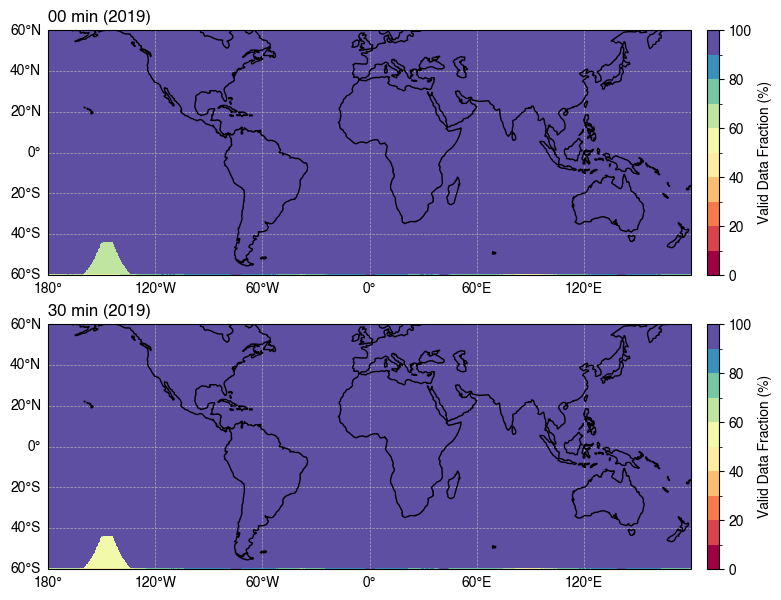

In [41]:
levels = np.arange(0, 100.1, 10)
cbticks = np.arange(0, 100.1, 20)
cblabel = 'Valid Data Fraction (%)'
cmap = 'Spectral'

iyear = 2019
titles = [f'00 min ({iyear})', f'30 min ({iyear})']
figname = f'{figdir}merg_validdata_frac_{iyear}.png'
dataarr = [frac00_year.sel(year=iyear)*100, frac30_year.sel(year=iyear)*100]
fig = plot_2maps(dataarr, levels, cmap, cblabel, cbticks, titles, figname)

In [44]:
figdir

'/Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/'

In [45]:
levels = np.arange(0, 100.1, 10)
cbticks = np.arange(0, 100.1, 20)
cblabel = 'Valid Data Fraction (%)'
cmap = 'Spectral'

# Loop over each year
for iyear in range(min_year, max_year+1):
#     print(iyear)
#     print(years.values[ii])
#     print(frac00_year.sel(year=years.values[ii]).shape)
    titles = [f'00 min ({iyear})', f'30 min ({iyear})']
    figname = f'{figdir}merg_validdata_frac_{iyear}.png'
    dataarr = [frac00_year.sel(year=iyear)*100, frac30_year.sel(year=iyear)*100]
    fig = plot_2maps(dataarr, levels, cmap, cblabel, cbticks, titles, figname)
    plt.close(fig)
    print(f'Figure saved: {figname}')

Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_1998.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_1999.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2000.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2001.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2002.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2003.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2004.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2005.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2006.png
Figure saved: /Users/feng045/data/gpm/IR_IMERG_Combined_V07B/stats/merg_validdata_frac_2007.png
Figure saved: /Users/feng045/data/gpm/IR

In [46]:
f'{min_year}-{max_year}'

'1998-2024'

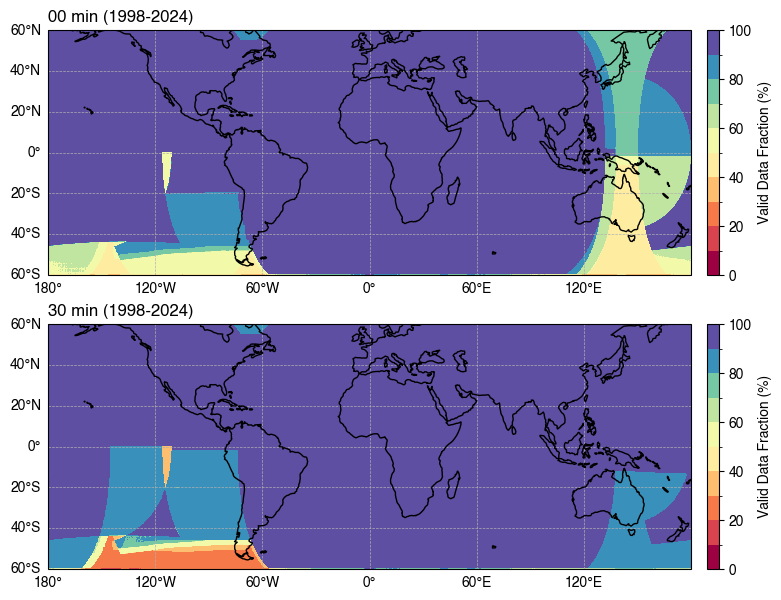

In [47]:
dataarr = [frac00_all*100, frac30_all*100]
levels = np.arange(0, 100.1, 10)
cbticks = np.arange(0, 100.1, 20)
cblabel = 'Valid Data Fraction (%)'
cmap = 'Spectral'
titles = [f'00 min ({min_year}-{max_year})', f'30 min ({min_year}-{max_year})']
figname = f'{figdir}merg_validdata_frac_{min_year}-{max_year}.png'
fig = plot_2maps(dataarr, levels, cmap, cblabel, cbticks, titles, figname)